In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# -- Generator to get unique figure ids --
def fig_id_generator():
    i = 1
    while True:
        yield i
        i += 1
fig_id = fig_id_generator()

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.FashionMNIST("F_MNIST_data", download = True, train = True, transform = transform )
test_dataset = datasets.FashionMNIST("F_MNIST_data", download = True, train = False, transform = transform )

indices = list(range(len(train_dataset)))
np.random.shuffle(indices)
split = int (0.2 * len (train_dataset))
val_ids , train_ids = indices[:split], indices[split:]

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.5MB/s]


In [5]:
train_sampler = torch.utils.data.SubsetRandomSampler(train_ids)
val_sampler = torch.utils.data.SubsetRandomSampler(val_ids)

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size = BATCH_SIZE, sampler = train_sampler)
val_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size = BATCH_SIZE, sampler = val_sampler)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size = BATCH_SIZE, shuffle = False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Length of train data is 48000
Length of test data is 10000
Length of validation data is 12000
torch.Size([1, 28, 28]) torch.Size([128])
Sandal


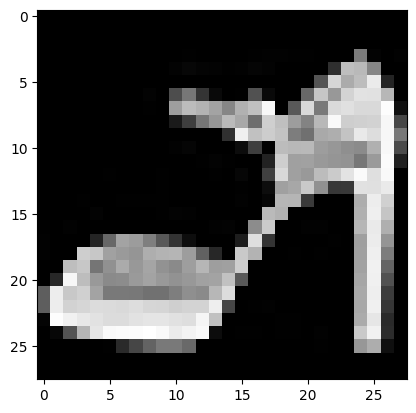

In [6]:
print("Length of train data is " + str(len(train_sampler)))
print("Length of test data is " + str(len(test_dataset)))
print("Length of validation data is " + str(len(val_sampler)))

image, label = next(iter(train_loader))
print(image[0].shape, label.shape)

desc = ["T-shirt/top ", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
print(desc[label[0].item()])
plt.imshow(image[0].numpy().squeeze(), cmap="gray")

In [8]:
class BaseCNN(nn.Module):
    def __init__(self, k=2, s=1, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.0, batch_norm=False):
        super(BaseCNN, self).__init__()
        self.num_blocks = num_blocks
        self.conv_layers = nn.ModuleList()

        in_channels = 1
        current_size = 28

        for i in range(num_blocks):
            # Use padding to try and keep spatial dimensions if s=1
            padding = (k - 1) // 2 if s == 1 else (k // 2)
            conv = nn.Conv2d(in_channels, filters, kernel_size=k, stride=s, padding=padding)
            self.conv_layers.append(conv)

            if batch_norm:
                self.conv_layers.append(nn.BatchNorm2d(filters))

            self.conv_layers.append(nn.ReLU())

            # Update size after conv
            current_size = (current_size + 2 * padding - k) // s + 1

            if current_size > 1:
                self.conv_layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
                current_size = current_size // 2

            in_channels = filters

        self.flat_size = filters * current_size * current_size

        self.fc = nn.Sequential(
            nn.Linear(self.flat_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity(),
            nn.Linear(fc_hidden, 10)
        )

    def forward(self, x, return_activations=False):
        activations = []
        for layer in self.conv_layers:
            x = layer(x)
            if isinstance(layer, nn.Conv2d):
                if return_activations:
                    activations.append(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        if return_activations:
            return x, activations
        return x

In [9]:
def train_and_report(model, num_epochs=50, lr=0.001):
    model.to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params}")

    test_image, _ = next(iter(test_loader))
    test_image = test_image[0:1].to(device)
    
    train_losses = []
    val_losses = []

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.sampler)
        train_losses.append(train_loss)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * images.size(0)
        val_loss = v_loss / len(val_loader.sampler)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            with torch.no_grad():
                _, activations = model(test_image, return_activations=True)
                num_convs = len(activations)
                fig, axes = plt.subplots(1, num_convs, figsize=(num_convs * 3, 3))
                if num_convs == 1: axes = [axes]
                for i, act in enumerate(activations):
                    axes[i].imshow(act[0, 0].cpu().detach().numpy(), cmap='viridis')
                    axes[i].set_title(f"Conv {i+1}")
                    axes[i].axis('off')
                plt.suptitle(f"Epoch {epoch+1} Activations")
                plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
                plt.show()

    def get_accuracy(loader):
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        return 100 * correct / total

    print(f"Final Accuracies: Train: {get_accuracy(train_loader):.2f}%, Val: {get_accuracy(val_loader):.2f}%, Test: {get_accuracy(test_loader):.2f}%")

    plt.figure()
    plt.plot(range(1, num_epochs + 1), train_losses, 'o-', label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, 'o-', label='Val Loss')
    plt.title('Loss History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
    plt.show()
    return get_accuracy(test_loader)

# Experiment 1: Baseline

Experiment 1: Baseline
Total Trainable Parameters: 50314
Epoch 1/50, Train Loss: 0.7333, Val Loss: 0.5294


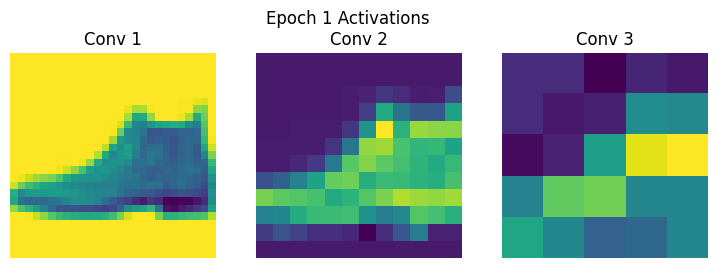

Epoch 10/50, Train Loss: 0.2646, Val Loss: 0.3054


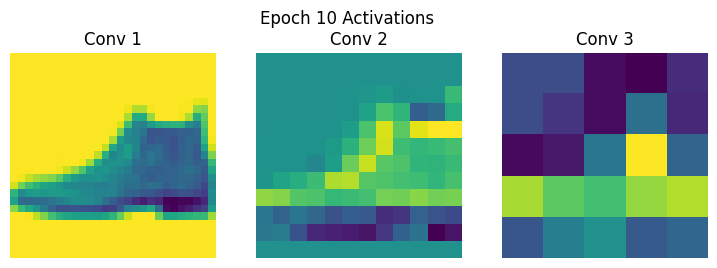

Epoch 20/50, Train Loss: 0.1827, Val Loss: 0.3110


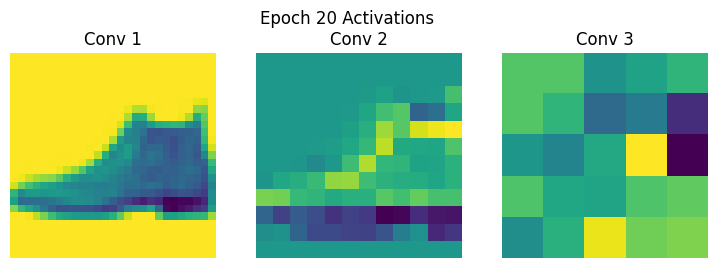

Epoch 30/50, Train Loss: 0.1256, Val Loss: 0.3463


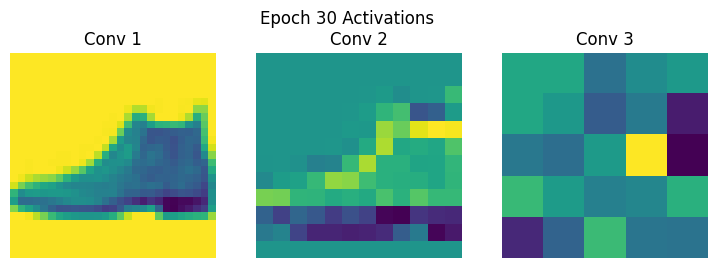

Epoch 40/50, Train Loss: 0.0884, Val Loss: 0.4516


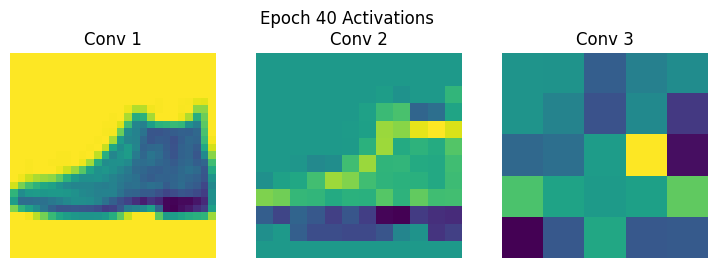

Epoch 50/50, Train Loss: 0.0622, Val Loss: 0.5607


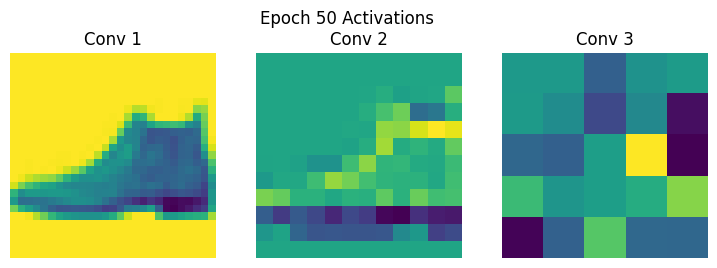

Final Accuracies: Train: 97.44%, Val: 88.62%, Test: 88.24%


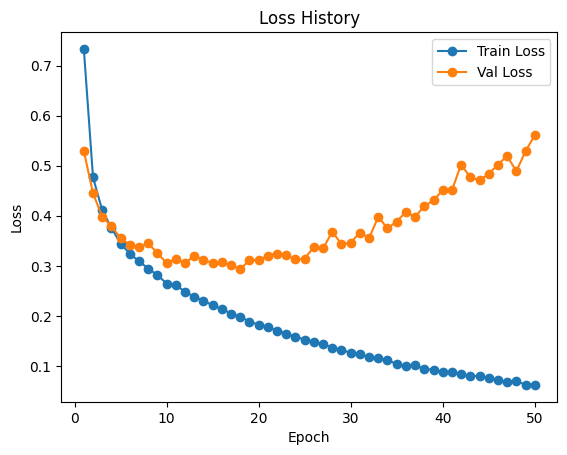

In [10]:
model_baseline = BaseCNN(k=2, s=1, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.0, batch_norm=False)
baseline_acc = train_and_report(model_baseline, num_epochs=50)

# Experiment 2: Kernel Size and Stride Ablation

Experiment 2: Kernel Size and Stride Ablation
Total Trainable Parameters: 211402
Epoch 1/50, Train Loss: 0.6746, Val Loss: 0.4608


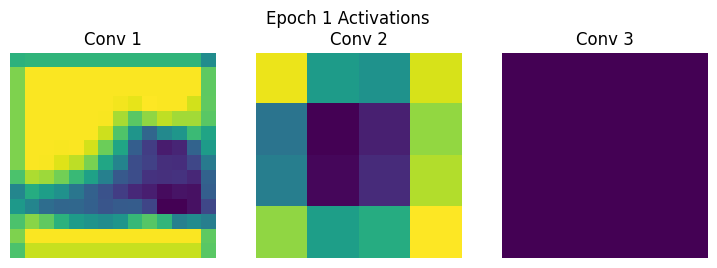

Epoch 10/50, Train Loss: 0.1843, Val Loss: 0.2525


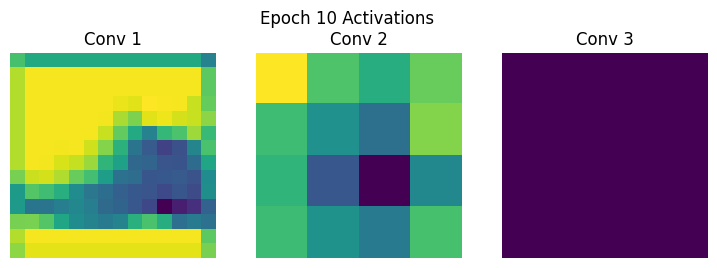

Epoch 20/50, Train Loss: 0.0857, Val Loss: 0.3128


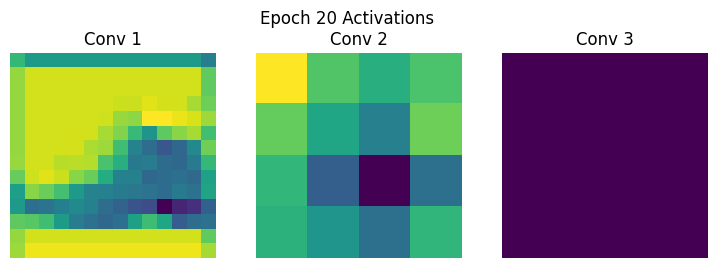

Epoch 30/50, Train Loss: 0.0398, Val Loss: 0.4987


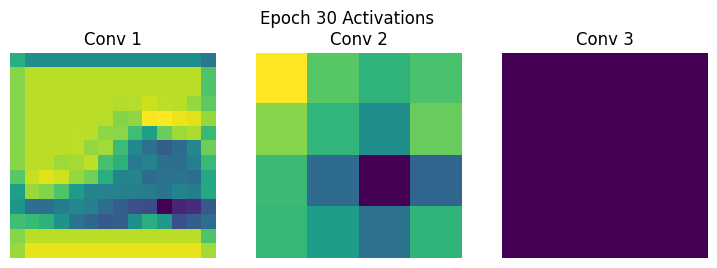

Epoch 40/50, Train Loss: 0.0313, Val Loss: 0.5306


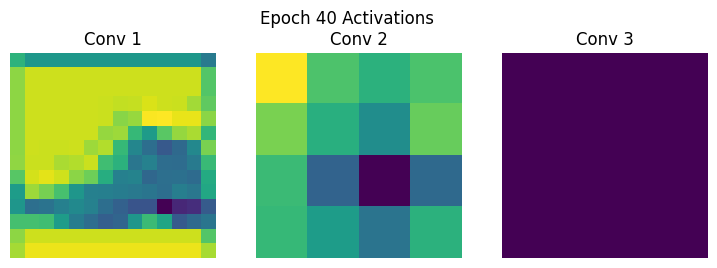

Epoch 50/50, Train Loss: 0.0272, Val Loss: 0.6256


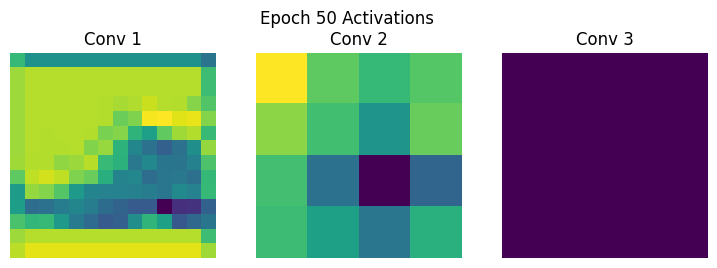

Final Accuracies: Train: 99.45%, Val: 90.63%, Test: 90.19%


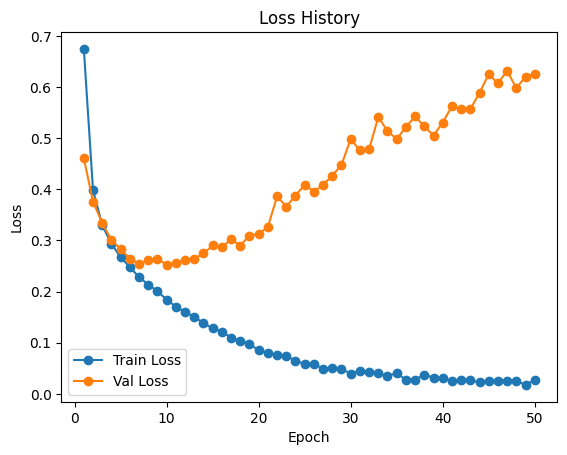

In [12]:
model_ks = BaseCNN(k=5, s=2, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.0, batch_norm=False)
ks_acc = train_and_report(model_ks, num_epochs=50)

# Experiment 3: Depth Ablation (shallower)

Experiment 3: Depth Ablation (shallower)
Total Trainable Parameters: 164938
Epoch 1/50, Train Loss: 0.5815, Val Loss: 0.4054


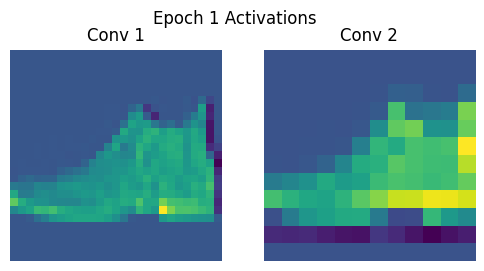

Epoch 10/50, Train Loss: 0.1881, Val Loss: 0.2524


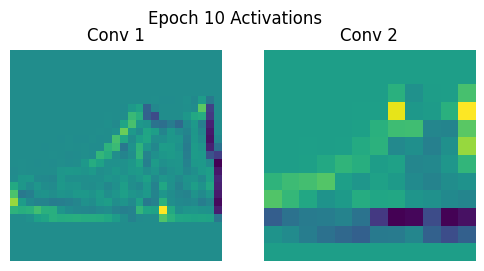

Epoch 20/50, Train Loss: 0.0924, Val Loss: 0.3127


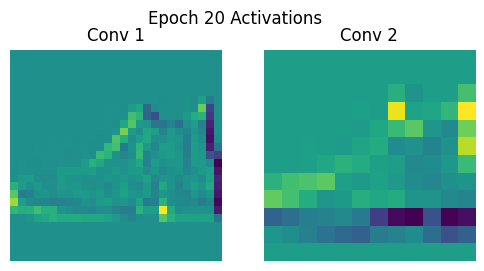

Epoch 30/50, Train Loss: 0.0410, Val Loss: 0.4491


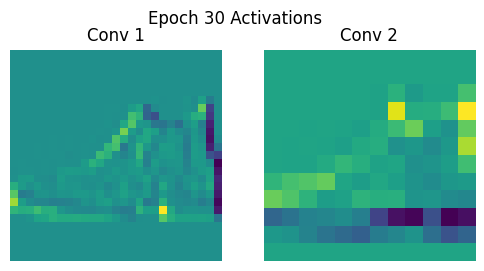

Epoch 40/50, Train Loss: 0.0256, Val Loss: 0.6016


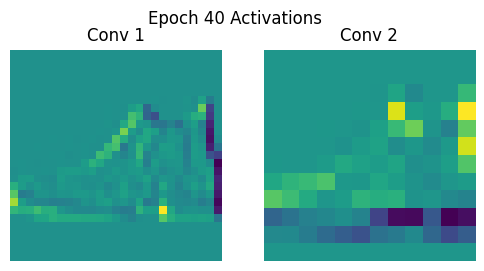

Epoch 50/50, Train Loss: 0.0202, Val Loss: 0.6897


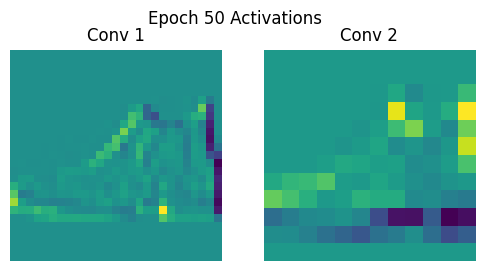

Final Accuracies: Train: 99.31%, Val: 90.11%, Test: 90.24%


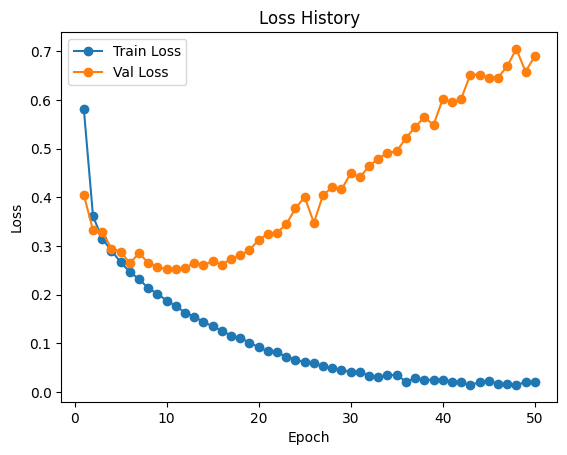

In [11]:
model_shallow = BaseCNN(k=2, s=1, num_blocks=2, filters=64, fc_hidden=64, dropout_p=0.0, batch_norm=False)
shallow_acc = train_and_report(model_shallow, num_epochs=50)

# Experiment 4: Dropout (p = 0.25)

Experiment 4: Dropout (p = 0.25)
Total Trainable Parameters: 50314
Epoch 1/50, Train Loss: 0.8317, Val Loss: 0.5271


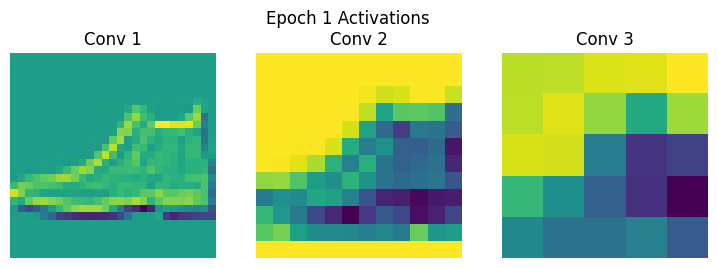

Epoch 10/50, Train Loss: 0.3154, Val Loss: 0.3161


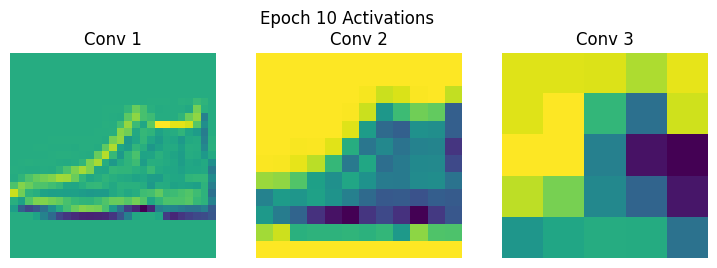

Epoch 20/50, Train Loss: 0.2469, Val Loss: 0.2894


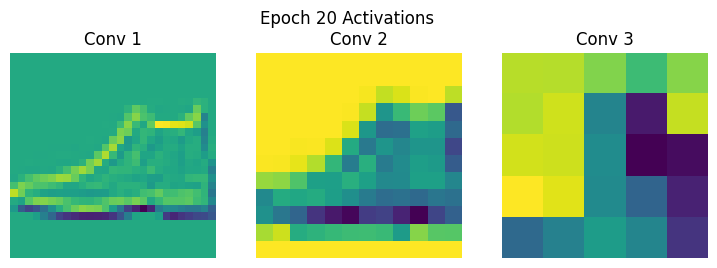

Epoch 30/50, Train Loss: 0.2022, Val Loss: 0.3064


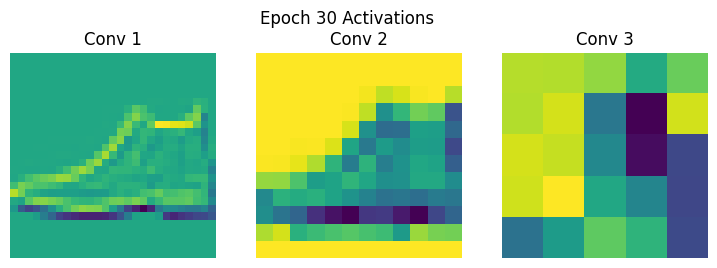

Epoch 40/50, Train Loss: 0.1711, Val Loss: 0.3313


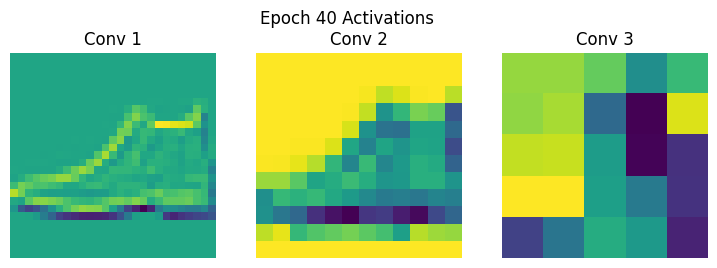

Epoch 50/50, Train Loss: 0.1520, Val Loss: 0.3624


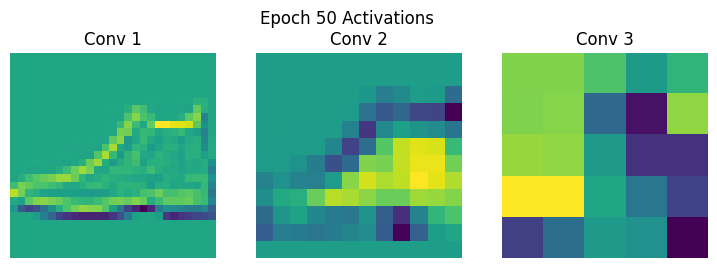

Final Accuracies: Train: 95.32%, Val: 89.01%, Test: 89.19%


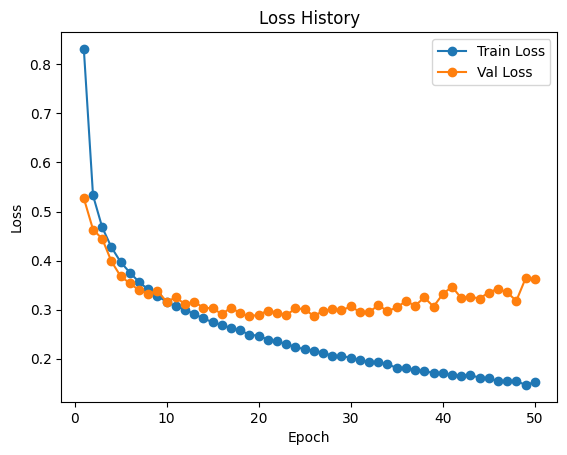

In [13]:
model_dropout = BaseCNN(k=2, s=1, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.25, batch_norm=False)
dropout_acc = train_and_report(model_dropout, num_epochs=50)

# Experiment 5: Batch Normalisation

Best performing model so far: Shallow (90.24%)
Retraining with Batch Normalization...
Total Trainable Parameters: 165194
Epoch 1/50, Train Loss: 0.4191, Val Loss: 0.3704


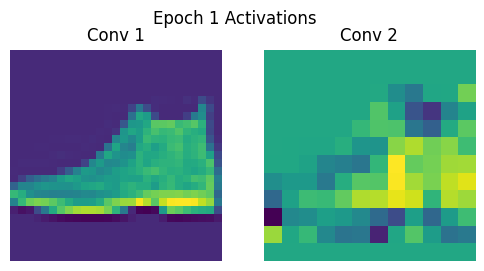

Epoch 10/50, Train Loss: 0.1354, Val Loss: 0.2513


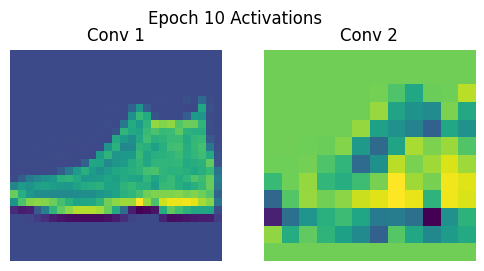

Epoch 20/50, Train Loss: 0.0496, Val Loss: 0.3380


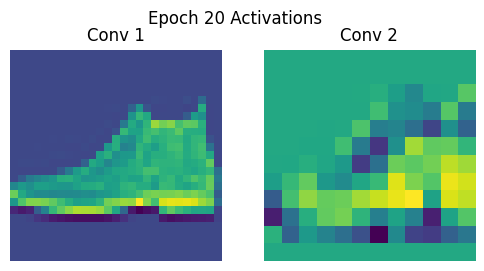

Epoch 30/50, Train Loss: 0.0197, Val Loss: 0.4337


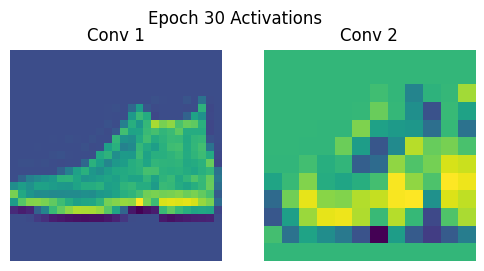

Epoch 40/50, Train Loss: 0.0210, Val Loss: 0.5534


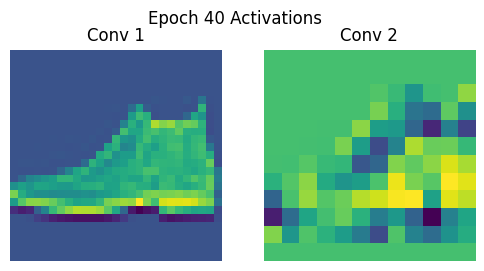

Epoch 50/50, Train Loss: 0.0204, Val Loss: 0.5564


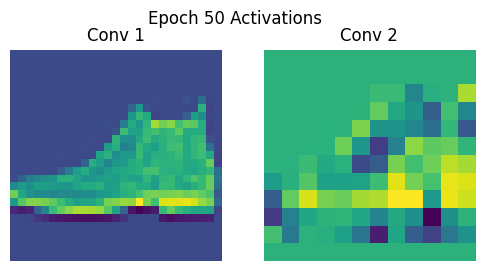

Final Accuracies: Train: 99.87%, Val: 91.62%, Test: 91.13%


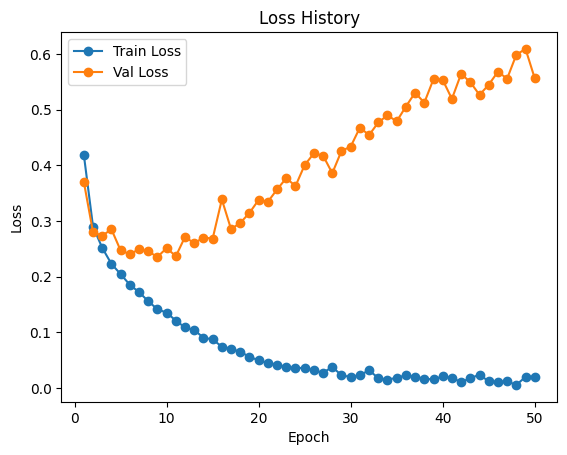

In [14]:
results = {
    "Baseline": baseline_acc,
    "KS/Stride": ks_acc,
    "Shallow": shallow_acc,
    "Dropout": dropout_acc
}
best_name = max(results, key=results.get)
print(f"Best performing model so far: {best_name} ({results[best_name]:.2f}%)")

if best_name == "Baseline":
    model_best_bn = BaseCNN(k=2, s=1, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.0, batch_norm=True)
elif best_name == "KS/Stride":
    model_best_bn = BaseCNN(k=5, s=2, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.0, batch_norm=True)
elif best_name == "Shallow":
    model_best_bn = BaseCNN(k=2, s=1, num_blocks=2, filters=64, fc_hidden=64, dropout_p=0.0, batch_norm=True)
else: # Dropout
    model_best_bn = BaseCNN(k=2, s=1, num_blocks=3, filters=64, fc_hidden=64, dropout_p=0.25, batch_norm=True)

print("Retraining with Batch Normalization...")
best_bn_acc = train_and_report(model_best_bn, num_epochs=50)